,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


Пропущені значення до очищення:
normalized-losses    41
num-of-doors          2
bore                  4
stroke                4
horsepower            2
peak-rpm              2
price                 4
dtype: int64

Пропущені значення після очищення:
0


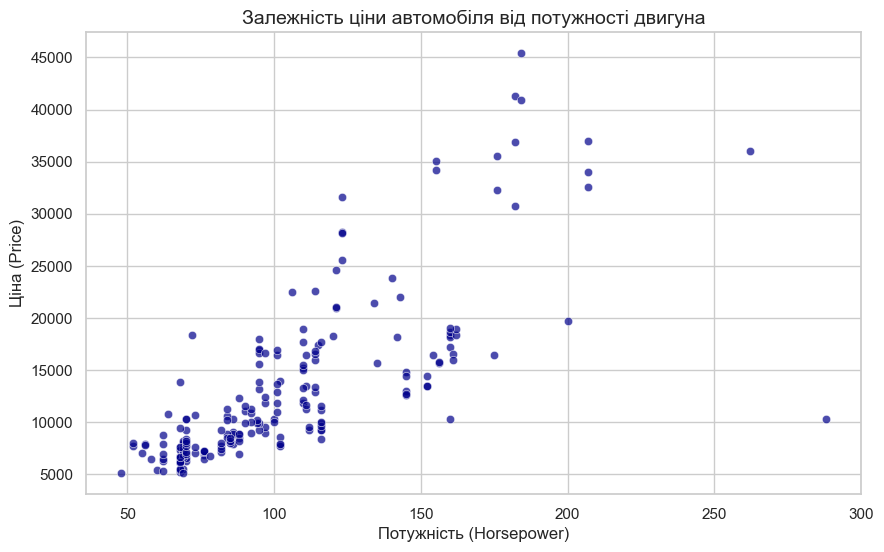

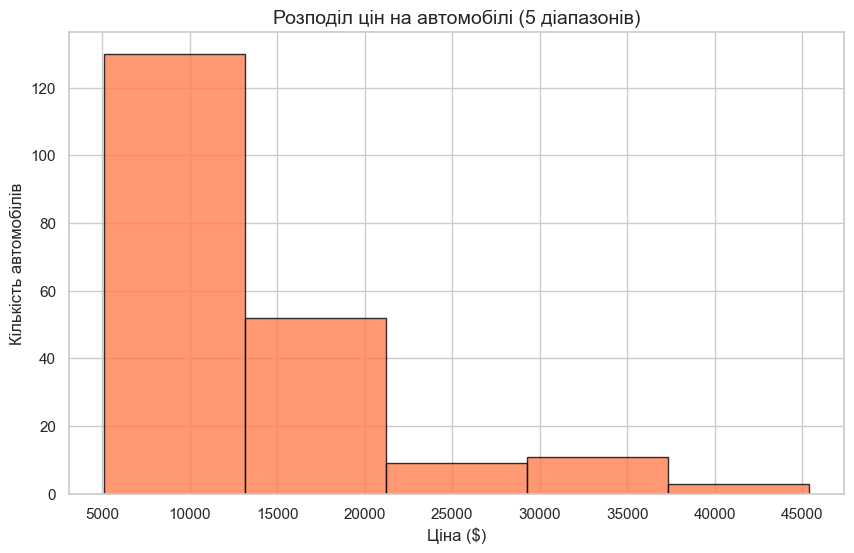

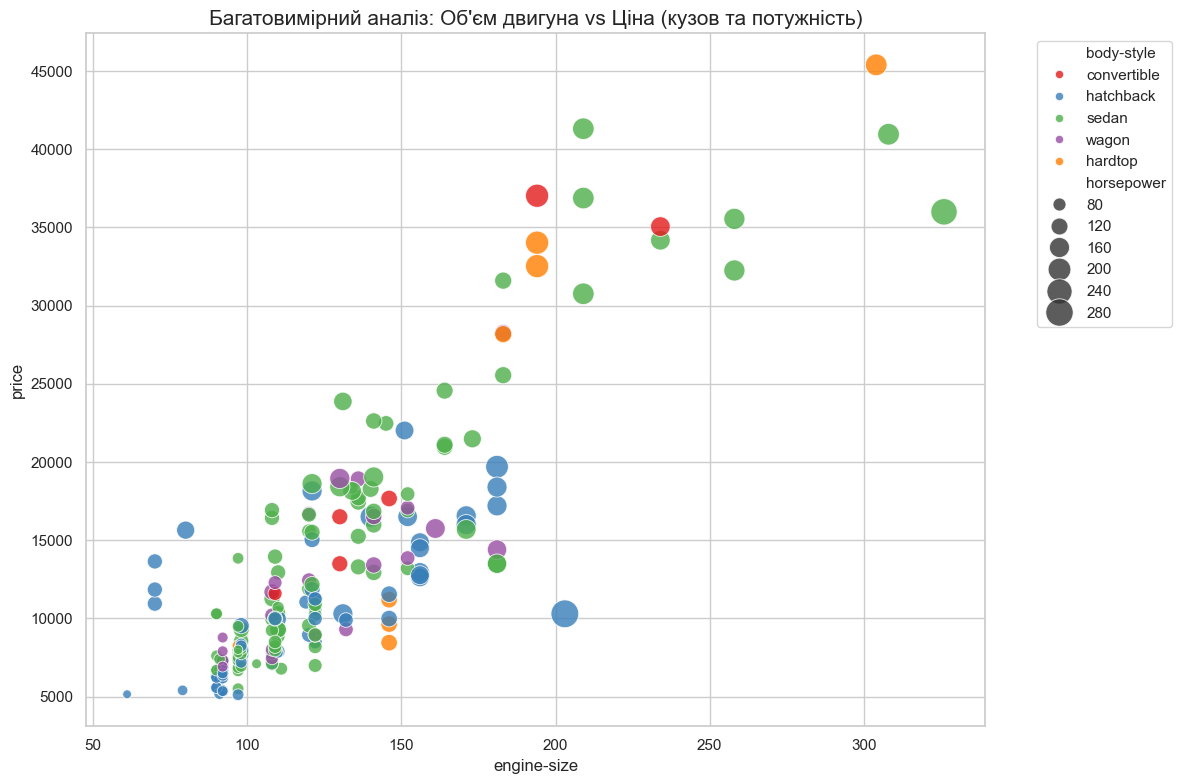

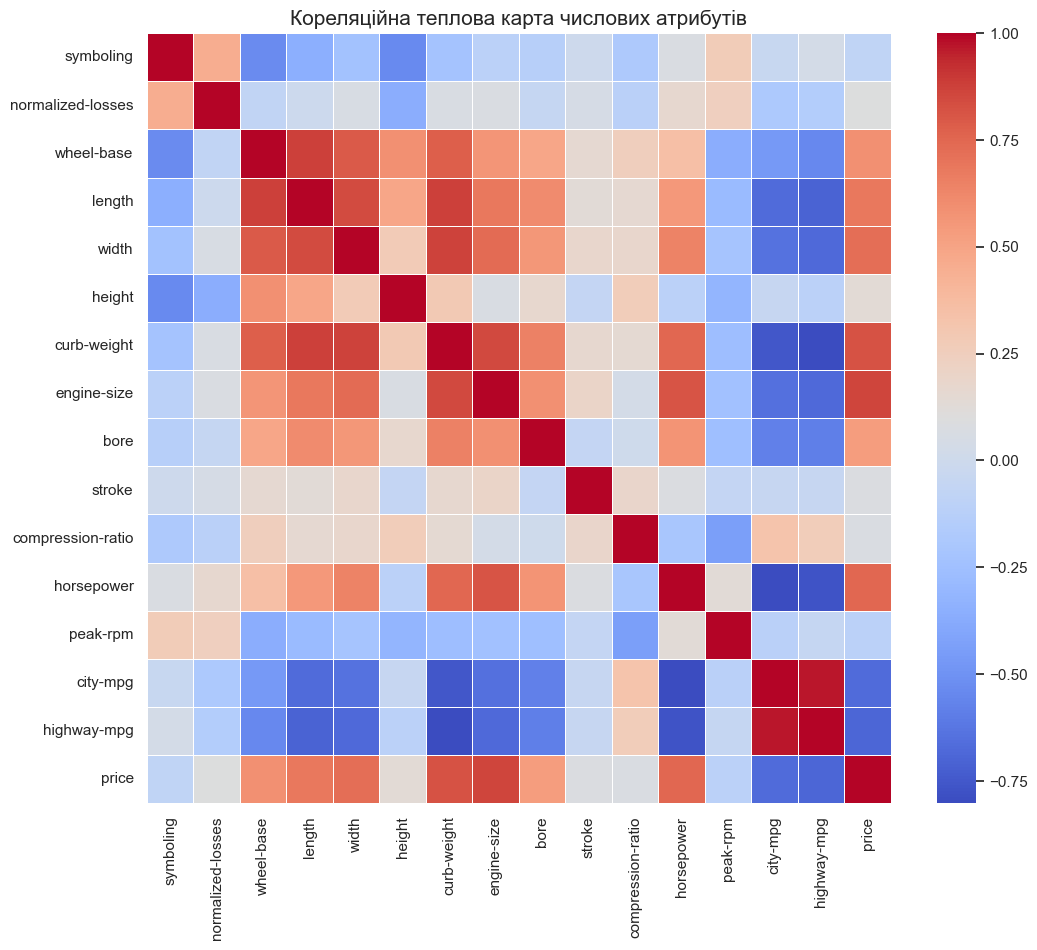

C:\Users\MORIARTY\AppData\Local\Temp\ipykernel_7072\2458819291.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='body-style', y='price', palette='pastel')


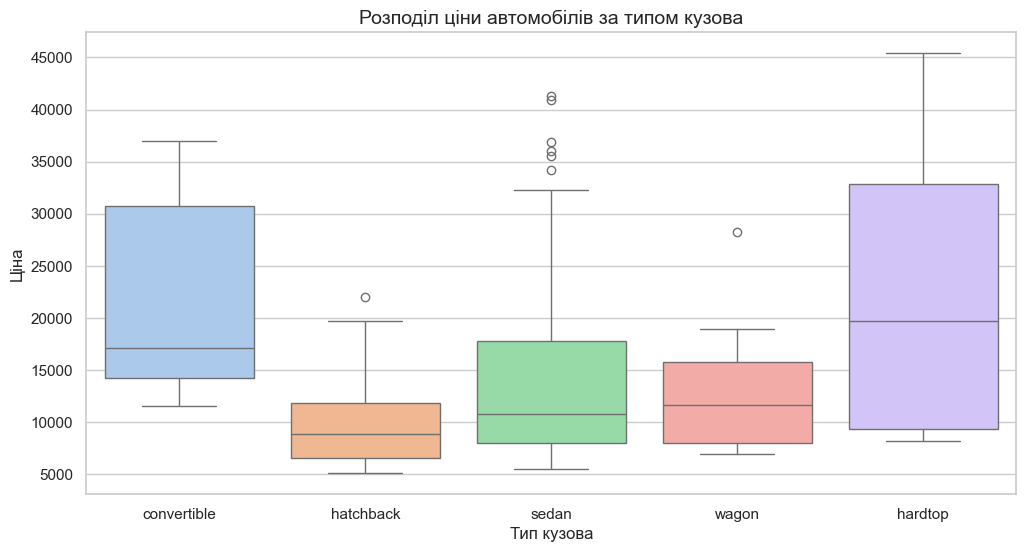

C:\Users\MORIARTY\AppData\Local\Temp\ipykernel_7072\2458819291.py:128: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='make', order=df['make'].value_counts().index, palette='viridis')


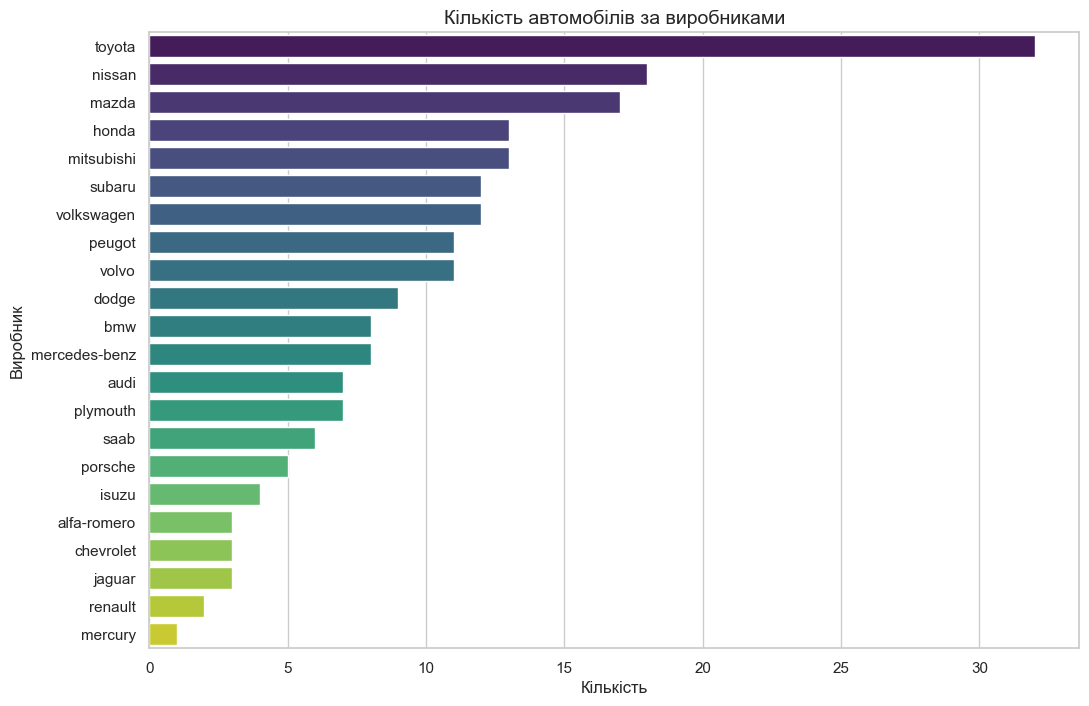

C:\Users\MORIARTY\AppData\Local\Temp\ipykernel_7072\2458819291.py:140: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='fuel-type', y='price', palette='muted', split=True)


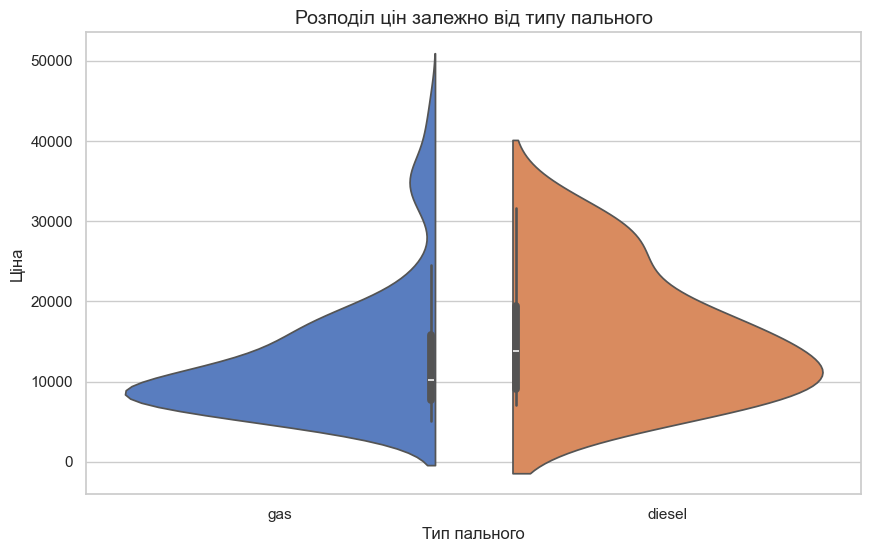

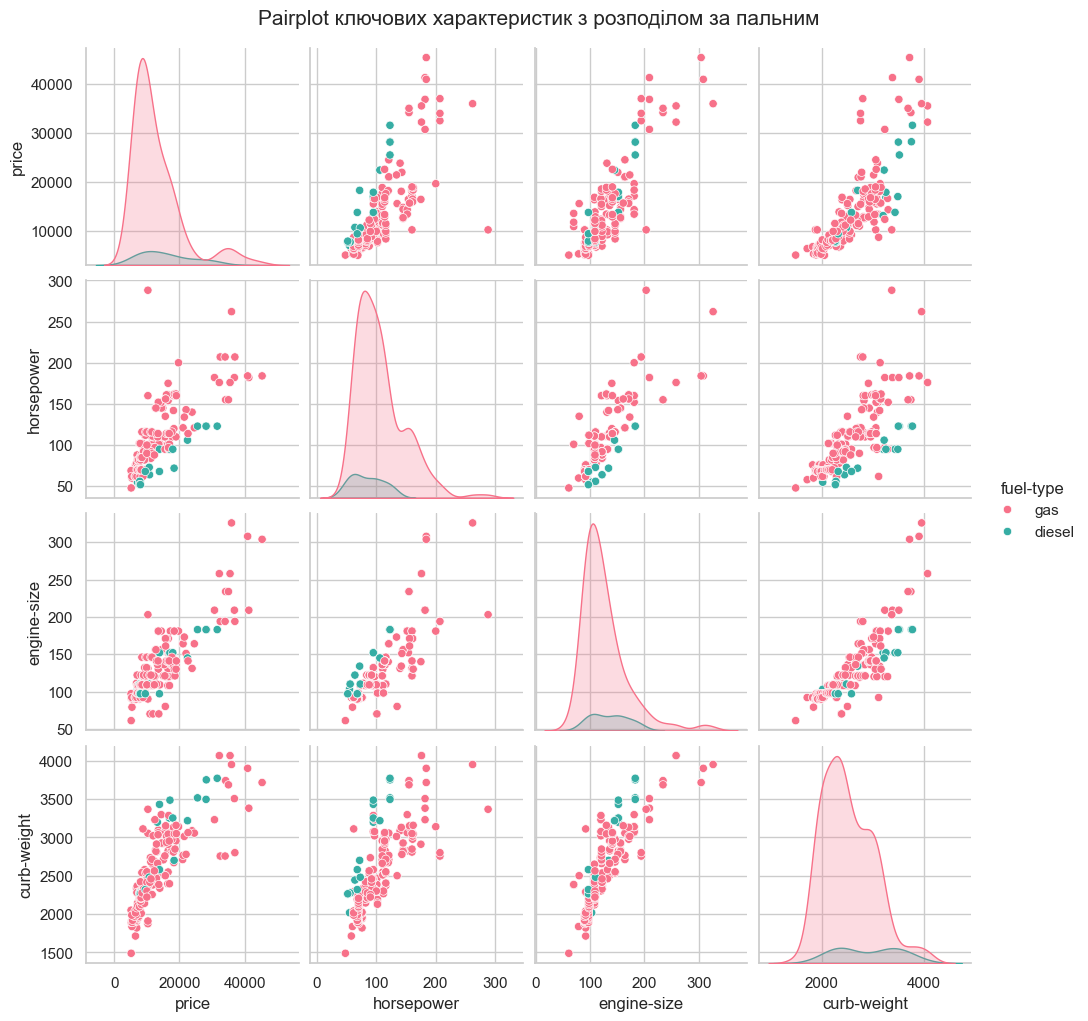

In [3]:
# %% [markdown]
# # Лабораторна робота №3: Візуалізація даних
# **Студент:** Moriarty (ФБ-44)
# **Датасет:** Automobile Data Set (UCI)

# %% [markdown]
# ## 1. Завантаження даних та імпорт бібліотек

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування стилю для графіків
sns.set_theme(style="whitegrid")

# Завантаження датасету Automobile з UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
columns = [
    "symboling", "normalized-losses", "make", "fuel-type", "aspiration",
    "num-of-doors", "body-style", "drive-wheels", "engine-location",
    "wheel-base", "length", "width", "height", "curb-weight", "engine-type",
    "num-of-cylinders", "engine-size", "fuel-system", "bore", "stroke",
    "compression-ratio", "horsepower", "peak-rpm", "city-mpg", "highway-mpg", "price"
]

# Зчитуємо дані, вказуючи, що пропущені значення позначені як '?'
df = pd.read_csv(url, names=columns, na_values="?")

# Виводимо перші 5 рядків
display(df.head())

# %% [markdown]
# ## 2. Data Cleaning (Очищення даних)

# %%
# Перевірка на пропущені значення
print("Пропущені значення до очищення:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# 1. Заповнення пропусків у числових колонках медіанним значенням
numeric_cols_with_na = ["normalized-losses", "bore", "stroke", "horsepower", "peak-rpm", "price"]
for col in numeric_cols_with_na:
    df[col] = df[col].fillna(df[col].median())

# 2. Заповнення пропусків у категоріальних колонках модою (найчастішим значенням)
df['num-of-doors'] = df['num-of-doors'].fillna(df['num-of-doors'].mode()[0])

# Перевірка результату
print("\nПропущені значення після очищення:")
print(df.isnull().sum().sum()) # Має бути 0

# %% [markdown]
# ## 3. Побудова графіків (Візуалізація)

# %% [markdown]
# ### Графік 1: Залежність одного числового атрибута від іншого (Scatter plot)

# %%
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='horsepower', y='price', color='darkblue', alpha=0.7)
plt.title('Залежність ціни автомобіля від потужності двигуна', fontsize=14)
plt.xlabel('Потужність (Horsepower)', fontsize=12)
plt.ylabel('Ціна (Price)', fontsize=12)
plt.show()

# %% [markdown]
# ### Графік 2: Гістограма по одному з атрибутів на 5 діапазонів

# %%
plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=5, color='coral', edgecolor='black', alpha=0.8)
plt.title('Розподіл цін на автомобілі (5 діапазонів)', fontsize=14)
plt.xlabel('Ціна ($)', fontsize=12)
plt.ylabel('Кількість автомобілів', fontsize=12)
plt.show()

# %% [markdown]
# ### Графік 3: Багатовимірна візуалізація (Scatter з Hue та Size)
# *Використання прикладів багатовимірної візуалізації (4 виміри на одному графіку: X, Y, Колір, Розмір).*

# %%
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df, 
    x='engine-size', 
    y='price', 
    hue='body-style', 
    size='horsepower', 
    sizes=(40, 400), 
    alpha=0.8,
    palette='Set1'
)
plt.title('Багатовимірний аналіз: Об\'єм двигуна vs Ціна (кузов та потужність)', fontsize=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# %% [markdown]
# ### Графік 4: Кореляційна матриця (Heatmap)
# *Показує взаємозв'язок між усіма числовими атрибутами.*

# %%
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=[np.number]) # Тільки числові дані
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Кореляційна теплова карта числових атрибутів', fontsize=15)
plt.show()

# %% [markdown]
# ### Графік 5: Boxplot (Ящик з вусами)
# *Дозволяє виявити викиди у ціні в залежності від типу кузова.*

# %%
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='body-style', y='price', palette='pastel')
plt.title('Розподіл ціни автомобілів за типом кузова', fontsize=14)
plt.xlabel('Тип кузова', fontsize=12)
plt.ylabel('Ціна', fontsize=12)
plt.show()

# %% [markdown]
# ### Графік 6: Barplot (Кількісний розподіл категоріального атрибута)

# %%
plt.figure(figsize=(12, 8))
sns.countplot(data=df, y='make', order=df['make'].value_counts().index, palette='viridis')
plt.title('Кількість автомобілів за виробниками', fontsize=14)
plt.xlabel('Кількість', fontsize=12)
plt.ylabel('Виробник', fontsize=12)
plt.show()

# %% [markdown]
# ### Графік 7: Violin Plot
# *Комбінує Boxplot та ядерну оцінку щільності (KDE).*

# %%
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='fuel-type', y='price', palette='muted', split=True)
plt.title('Розподіл цін залежно від типу пального', fontsize=14)
plt.xlabel('Тип пального', fontsize=12)
plt.ylabel('Ціна', fontsize=12)
plt.show()

# %% [markdown]
# ### Графік 8: Pairplot
# *Матриця діаграм розсіяння для швидкого аналізу кількох ключових характеристик одночасно.*

# %%
key_features = ['price', 'horsepower', 'engine-size', 'curb-weight', 'fuel-type']
sns.pairplot(df[key_features], hue='fuel-type', diag_kind='kde', palette='husl')
plt.suptitle('Pairplot ключових характеристик з розподілом за пальним', y=1.02, fontsize=15)
plt.show()